In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [27]:
df_movies = pd.read_csv('../../../data/raw/lecture/tmdb_5000_movies.csv')
df_credits = pd.read_csv('../../../data/raw/lecture/tmdb_5000_credits.csv')

In [28]:
print(len(df_movies))
print(len(df_credits))

4803
4803


In [29]:
print(df_movies.columns)
print(df_credits.columns)

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='str')
Index(['movie_id', 'title', 'cast', 'crew'], dtype='str')


In [30]:
df = df_movies.merge(df_credits, left_on='id', right_on='movie_id', suffixes=('_movies', '_credits'))

In [31]:
df.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_movies,vote_average,vote_count,movie_id,title_credits,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [32]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989,57165.484281
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891,88694.614033
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,5.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000,9014.500000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000,14629.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000,58610.500000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000,459488.000000


In [35]:
df[df['release_date'].isna()]

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_movies,vote_average,vote_count,movie_id,title_credits,cast,crew
4553,0,[],NaN,380097,[],en,America Is Still the Place,1971 post civil rights San Francisco seemed li...,0.0,[],...,[],Released,NaN,America Is Still the Place,0.0,0,380097,America Is Still the Place,[],[]


In [38]:
df = df.drop(index=4553)
len(df)

4802

In [40]:
df['year'] = df['release_date'].apply(lambda x: x[:4])
df['year']

0       2009
1       2007
2       2015
3       2012
4       2012
        ... 
4798    1992
4799    2011
4800    2013
4801    2012
4802    2005
Name: year, Length: 4802, dtype: str

In [41]:
df.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,status,tagline,title_movies,vote_average,vote_count,movie_id,title_credits,cast,crew,year
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2009
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2007
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",2015


In [51]:
y = df.groupby(by='year').count()['id']
y

year
1916      1
1925      1
1927      1
1929      2
1930      1
       ... 
2013    231
2014    238
2015    216
2016    104
2017      1
Name: id, Length: 90, dtype: int64

In [63]:
print(df['year'].min())
print(df['year'].max())

1916
2017


In [66]:
x = np.arange(1920, 2021, 20)
x

array([1920, 1940, 1960, 1980, 2000, 2020])

Text(0, 0.5, 'count')

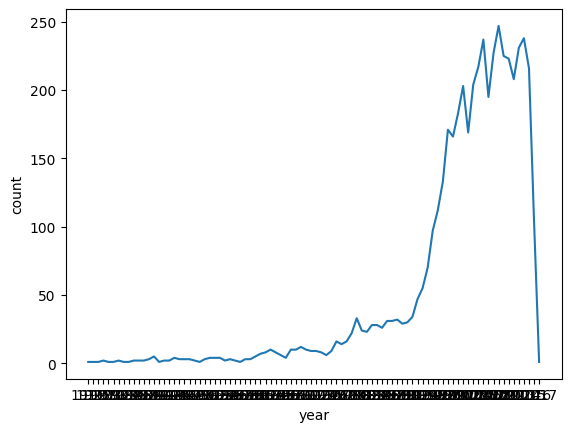

In [88]:
plt.plot(y)
plt.xlabel('year')
plt.ylabel('count')

In [110]:
mean = df[df['revenue'] != 0].groupby('year').mean(numeric_only=True)['revenue']
mean

year
1916    8.394751e+06
1925    2.200000e+07
1927    6.504220e+05
1929    4.358000e+06
1930    8.000000e+06
            ...     
2012    1.609447e+08
2013    1.436288e+08
2014    1.686748e+08
2015    1.807542e+08
2016    1.980980e+08
Name: revenue, Length: 89, dtype: float64

In [106]:
len(df[df['revenue'] != 0])

3376

In [105]:
len(df[df['revenue'] == 0])

1426

In [107]:
1426 + 3376

4802

In [111]:
median = df[df['revenue'] != 0].groupby('year').median(numeric_only=True)['revenue']
median

year
1916      8394751.0
1925     22000000.0
1927       650422.0
1929      4358000.0
1930      8000000.0
           ...     
2012     64793040.0
2013     63464861.0
2014     80383290.0
2015     84769058.0
2016    108286421.0
Name: revenue, Length: 89, dtype: float64

In [113]:
max = df[df['revenue'] != 0].groupby('year').max()['revenue']
max

year
1916       8394751
1925      22000000
1927        650422
1929       4358000
1930       8000000
           ...    
2012    1519557910
2013    1274219009
2014    1091405097
2015    1513528810
2016    1153304495
Name: revenue, Length: 89, dtype: int64

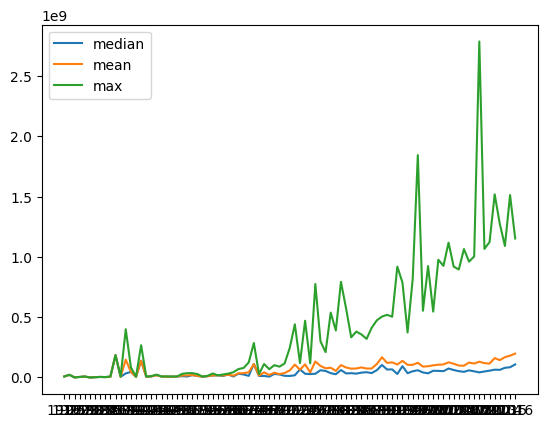

In [116]:
plt.plot(median, label='median')
plt.plot(mean, label='mean')
plt.plot(max, label='max')
plt.legend()

In [117]:
df[df['revenue'].isna()]

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,status,tagline,title_movies,vote_average,vote_count,movie_id,title_credits,cast,crew,year
